<a href="https://colab.research.google.com/github/kallydimitrova/HEPexercises/blob/main/Exercise3_Planck.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import numpy as np
import pandas as pd

def load_planck_tt(path, binned=True):
    """
    Load a Planck PR3 TT power spectrum file (binned or full/unbinned).
    Columns: ell, Dl, -dDl, +dDl [, BestFit] (whitespace-delimited,
    single '#'-comment header line).
    """
    colnames = ["ell", "Dl", "dDl_lo", "dDl_hi"]
    if binned:
        colnames.append("BestFit")

    df = pd.read_csv(path, comment="#", sep=r"\s+", header=None, names=colnames)

    return df

tt_binned = load_planck_tt("data/COM_PowerSpect_CMB-TT-binned_R3.01.txt", binned=True)
tt_full   = load_planck_tt("data/COM_PowerSpect_CMB-TT-full_R3.01.txt", binned=False)

print(tt_binned.head())

          ell          Dl     dDl_lo     dDl_hi     BestFit
0   47.711224  1479.33552  50.765488  50.765488  1461.11304
1   76.471606  2034.96833  54.710158  54.710158  2062.38073
2  105.917385  2955.39416  64.976644  64.976644  2904.52526
3  135.605348  3869.51392  76.914374  76.914374  3902.48963
4  165.405597  4889.46506  86.585626  86.585626  4861.35537


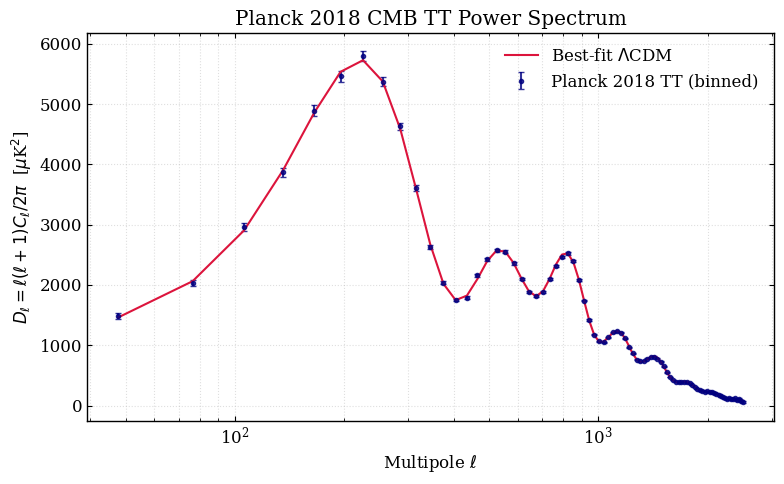

In [21]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 12, "font.family": "serif", "axes.linewidth": 1.0,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "legend.frameon": False, "savefig.bbox": "tight",
})

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    tt_binned["ell"], tt_binned["Dl"],
    yerr=[tt_binned["dDl_lo"], tt_binned["dDl_hi"]],
    fmt="o", color="navy", ecolor="navy", markersize=3,
    capsize=2, alpha=0.8, label="Planck 2018 TT (binned)"
)
ax.plot(tt_binned["ell"], tt_binned["BestFit"], "-", color="crimson",
        linewidth=1.5, label=r"Best-fit $\Lambda$CDM")

ax.set_xscale("log")
ax.set_xlabel(r"Multipole $\ell$")
ax.set_ylabel(r"$D_\ell = \ell(\ell+1)C_\ell/2\pi$  [$\mu$K$^2$]")
ax.set_title("Planck 2018 CMB TT Power Spectrum")
ax.grid(True, which="both", linestyle=":", alpha=0.4)
ax.legend()
fig.tight_layout()
fig.savefig("figures/tt_spectrum.png", dpi=300)

In [22]:
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

ell_grid = np.linspace(tt_binned["ell"].min(), tt_binned["ell"].max(), 5000)
interp_bestfit = interp1d(tt_binned["ell"], tt_binned["BestFit"], kind="cubic")
Dl_grid = interp_bestfit(ell_grid)

peak_idx, _ = find_peaks(Dl_grid, prominence=100)
peak_ells = ell_grid[peak_idx]
peak_Dls = Dl_grid[peak_idx]

for n, (l_pk, D_pk) in enumerate(zip(peak_ells, peak_Dls), start=1):
    print(f"Peak {n}: ell = {l_pk:.0f},  D_ell = {D_pk:.0f} muK^2")

Peak 1: ell = 221,  D_ell = 5733 muK^2
Peak 2: ell = 537,  D_ell = 2587 muK^2
Peak 3: ell = 813,  D_ell = 2536 muK^2
Peak 4: ell = 1127,  D_ell = 1239 muK^2


In [23]:
def theta_from_ell_simple(ell_1):
    """Crude estimate: theta ~ pi / ell_1 (Eq. 1.7)."""
    theta_rad = np.pi / ell_1
    return np.degrees(theta_rad)

ell_1_measured = peak_ells[0]
theta_simple_deg = theta_from_ell_simple(ell_1_measured)
print(f"Measured first peak: ell_1 = {ell_1_measured:.1f}")
print(f"Simple estimate: theta_sound ~ {theta_simple_deg:.3f} deg "
      f"({theta_simple_deg * 60:.1f} arcmin)")

theta_s_planck_deg = 0.5965  # 100*theta_MC ~ 1.04109 (Planck 2018 TT,TE,EE+lowE+lensing)
print(f"Planck precise value: theta_s ~ {theta_s_planck_deg:.4f} deg")
print(f"Fractional difference: "
      f"{100*(theta_simple_deg - theta_s_planck_deg)/theta_s_planck_deg:.1f}%")

Measured first peak: ell_1 = 220.8
Simple estimate: theta_sound ~ 0.815 deg (48.9 arcmin)
Planck precise value: theta_s ~ 0.5965 deg
Fractional difference: 36.7%


In [10]:
!pip install camb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 7.4 MB/s eta 0:00:00


In [24]:
import camb

def get_tt_spectrum(H0=67.4, ombh2=0.0224, omch2=0.120, tau=0.054,
                     ns=0.965, As=2.1e-9, omk=0.0, lmax=2500):

    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, tau=tau, omk=omk)
    pars.InitPower.set_params(ns=ns, As=As)
    pars.set_for_lmax(lmax, lens_potential_accuracy=1)

    results = camb.get_results(pars)
    powers = results.get_cmb_power_spectra(pars, CMB_unit="muK")
    totCL = powers["total"]  # columns: TT, EE, BB, TE

    ell = np.arange(totCL.shape[0])
    Dl_TT = totCL[:, 0]
    return ell, Dl_TT

ell_fid, Dl_fid = get_tt_spectrum()  # Planck 2018 best-fit parameters

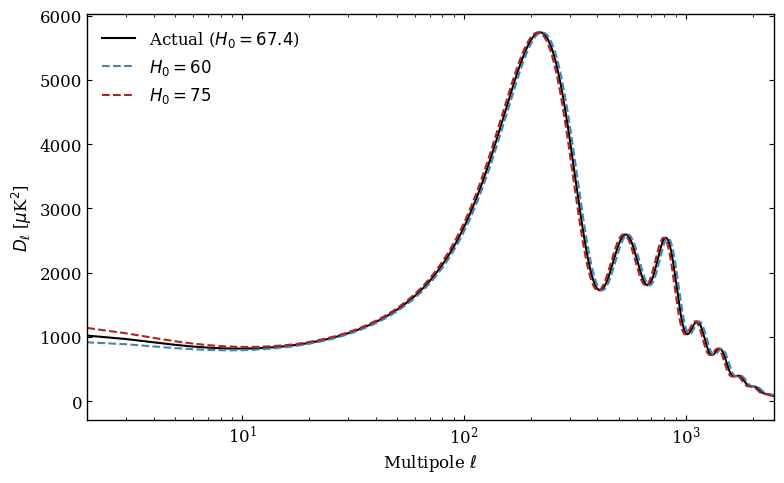

In [25]:
ell_H0_low,  Dl_H0_low  = get_tt_spectrum(H0=60.0)
ell_H0_high, Dl_H0_high = get_tt_spectrum(H0=75.0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ell_fid, Dl_fid, color="black", label=r"Actual ($H_0=67.4$)")
ax.plot(ell_H0_low, Dl_H0_low, "--", color="steelblue", label=r"$H_0=60$")
ax.plot(ell_H0_high, Dl_H0_high, "--", color="firebrick", label=r"$H_0=75$")
ax.set_xscale("log"); ax.set_xlim(2, 2500)
ax.set_xlabel(r"Multipole $\ell$"); ax.set_ylabel(r"$D_\ell$ [$\mu$K$^2$]")
ax.legend(); fig.tight_layout()

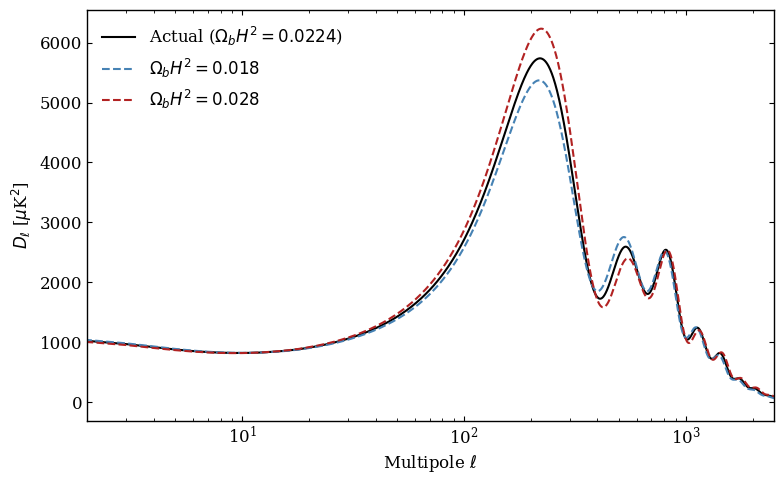

In [26]:
ell_ombh2_low,  Dl_ombh2_low  = get_tt_spectrum(ombh2=0.018)
ell_ombh2_high, Dl_ombh2_high = get_tt_spectrum(ombh2=0.028)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ell_fid, Dl_fid, color="black", label=r"Actual ($\Omega_{b}H^2=0.0224$)")
ax.plot(ell_ombh2_low, Dl_ombh2_low, "--", color="steelblue", label=r"$\Omega_{b}H^2=0.018$")
ax.plot(ell_ombh2_high, Dl_ombh2_high, "--", color="firebrick", label=r"$\Omega_{b}H^2=0.028$")
ax.set_xscale("log"); ax.set_xlim(2, 2500)
ax.set_xlabel(r"Multipole $\ell$"); ax.set_ylabel(r"$D_\ell$ [$\mu$K$^2$]")
ax.legend(); fig.tight_layout()

In [ ]:
ell_closed, Dl_closed = get_tt_spectrum(omk=-0.05)  # positively curved
ell_open,   Dl_open   = get_tt_spectrum(omk=+0.05)  # negatively curved

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ell_fid, Dl_fid, color="black", label=r"Actual")
ax.plot(ell_closed, Dl_closed, "--", color="steelblue", label=r"Positively curved")
ax.plot(ell_open, Dl_open, "--", color="firebrick", label=r"Negatively curved")
ax.set_xscale("log"); ax.set_xlim(2, 2500)
ax.set_xlabel(r"Multipole $\ell$"); ax.set_ylabel(r"$D_\ell$ [$\mu$K$^2$]")
ax.legend(); fig.tight_layout()

In [3]:
!pip install healpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 21.4 MB/s eta 0:00:00


Map resolution: nside = 2048  (~1.72 arcmin/pixel)
Map units from FITS header: 'K_CMB', std(cmb_map) = 1.084e-04
Converted K -> muK; std(cmb_map) is now 1.084e+02 muK


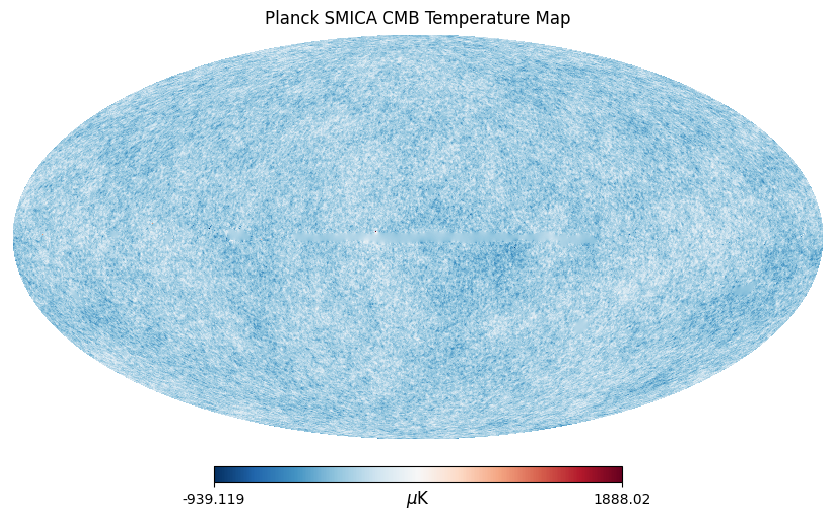

In [4]:

import healpy as hp

cmb_map, header = hp.read_map(
    "data/COM_CMB_IQU-smica_2048_R3.00_full.fits", field=0, h=True
)
nside = hp.get_nside(cmb_map)
print(f"Map resolution: nside = {nside}  (~{hp.nside2resol(nside, arcmin=True):.2f} arcmin/pixel)")

unit = dict(header).get("TUNIT1", "").strip().upper()
print(f"Map units from FITS header: {unit!r}, std(cmb_map) = {cmb_map.std():.3e}")
if unit in ("K_CMB", "K") or cmb_map.std() < 1e-3:
    cmb_map = cmb_map * 1e6  # K -> muK
    print(f"Converted K -> muK; std(cmb_map) is now {cmb_map.std():.3e} muK")

hp.mollview(cmb_map, title="Planck SMICA CMB Temperature Map", unit=r"$\mu$K",cmap="RdBu_r")


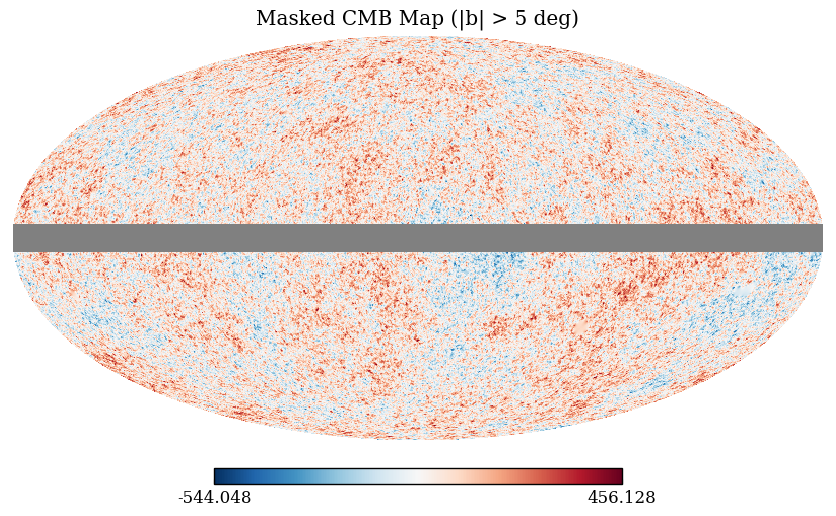

In [15]:
npix = hp.nside2npix(nside)
theta, phi = hp.pix2ang(nside, np.arange(npix))
gal_lat = 90.0 - np.degrees(theta)

mask = np.abs(gal_lat) > 5.0
masked_map = np.where(mask, cmb_map, hp.UNSEEN)
hp.mollview(masked_map, title="Masked CMB Map (|b| > 5 deg)", cmap="RdBu_r")

Sky fraction retained after the |b| > 20 deg cut: f_sky = 0.913


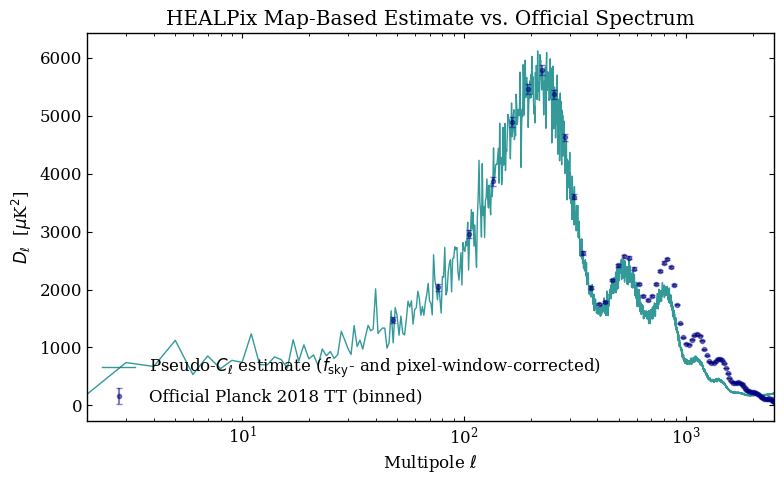

In [16]:
lmax = 2500

binary_mask = mask.astype(float)  # 1.0 = keep, 0.0 = masked out (from Task 2)
f_sky = binary_mask.sum() / binary_mask.size
print(f"Sky fraction retained after the |b| > 5 deg cut: f_sky = {f_sky:.3f}")

mean_unmasked = cmb_map[mask].mean()
map_for_anafast = (cmb_map - mean_unmasked) * binary_mask

cl_raw = hp.anafast(map_for_anafast, lmax=lmax)
ell_est = np.arange(len(cl_raw))

cl_fsky_corrected = cl_raw / f_sky

pixwin = hp.pixwin(nside, lmax=lmax)
cl_corrected = cl_fsky_corrected / pixwin**2

Dl_estimated = ell_est * (ell_est + 1) * cl_corrected / (2 * np.pi)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ell_est[2:], Dl_estimated[2:], color="teal", alpha=0.8, linewidth=1,
        label=r"Pseudo-$C_\ell$ estimate ($f_{\rm sky}$- and pixel-window-corrected)")
ax.errorbar(tt_binned["ell"], tt_binned["Dl"],
            yerr=[tt_binned["dDl_lo"], tt_binned["dDl_hi"]],
            fmt="o", color="navy", markersize=3, capsize=2, alpha=0.5,
            label="Official Planck 2018 TT (binned)")
ax.set_xscale("log")
ax.set_xlim(2, lmax)
ax.set_xlabel(r"Multipole $\ell$")
ax.set_ylabel(r"$D_\ell$  [$\mu$K$^2$]")
ax.set_title("HEALPix Map-Based Estimate vs. Official Spectrum")
ax.legend()
fig.tight_layout()
fig.savefig("figures/healpix_vs_official_spectrum.png", dpi=300)